![CREWS UFFFS Nowcast](logo.png)

# Tutorial 1: Download, pre-process, and analyse GSMaP satellite rainfall observations

This tutorial guides you step by step to:

1. Set up access to Google Earth Engine.
2. Download GSMaP hourly rainfall-rate data for a selected event period.
3. Convert the downloaded GeoTIFF files into one NetCDF file.
4. Inspect rainfall fields, rainfall quality, accumulation totals, and city zooms.

The goal is to help you become familiar with GSMaP rainfall data and to prepare a clean input dataset for the nowcasting notebook.

In this training we use **Phnom Penh** and **Vientiane** as example locations. You can replace these cities with your own stations, towns, catchments, or flood-prone areas.

# Step 1: Import the necessary libraries

We start by loading the Python libraries used in this notebook. If you are running the prepared Pixi environment, these packages should already be installed.

The most important libraries are:

- `earthengine-api` for accessing Google Earth Engine.
- `xarray` for working with multidimensional rainfall data.
- `rioxarray` and `rasterio` for reading GeoTIFF files.
- `pandas` for tables and timestamps.
- `matplotlib` for plotting.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import zipfile
import shutil
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import requests
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)

print("Libraries imported.")

Libraries imported.


# Step 2a: Select the event time period

This is the cell most workshop participants will edit during exercises.

Define the **start** and **end** time of the rainfall event you want to
download from GSMaP. A few notes:

- All times are in **UTC**.
- GSMaP is hourly, so use full-hour timestamps (`HH:00:00`).
- The end time is **exclusive**: setting end to `12:00` together with start
  `00:00` gives 12 hourly fields (00, 01, ..., 11).
- For a real event, choose a window that covers a few hours before the
  expected rainfall peak through a few hours after, so motion can be
  estimated reliably for the nowcast.
- A duration of 6–24 hours works well for testing. Longer windows mean
  more downloads from Google Earth Engine.


In [2]:
# ---------------------------------------------------------------------
# Edit these two lines to change the event period.
# ---------------------------------------------------------------------
EVENT_START = "2025-09-16T00:00:00Z"   # inclusive, UTC
EVENT_END   = "2025-09-16T12:00:00Z"   # exclusive, UTC

# ---------------------------------------------------------------------
# Quick sanity check on the selected period.
# ---------------------------------------------------------------------
_start_dt = pd.to_datetime(EVENT_START, utc=True)
_end_dt   = pd.to_datetime(EVENT_END,   utc=True)
_n_hours  = int((_end_dt - _start_dt).total_seconds() // 3600)

if _end_dt <= _start_dt:
    raise ValueError(
        f"EVENT_END ({EVENT_END}) must be strictly after EVENT_START ({EVENT_START})."
    )

print(f"Event start (UTC):     {_start_dt}")
print(f"Event end   (UTC):     {_end_dt}")
print(f"Duration:              {_n_hours} hours")
print(f"Expected GSMaP fields: {_n_hours} hourly images")


Event start (UTC):     2025-09-16 00:00:00+00:00
Event end   (UTC):     2025-09-16 12:00:00+00:00
Duration:              12 hours
Expected GSMaP fields: 12 hourly images


# Step 2b: Define the remaining workshop settings

The cell below holds all other settings: the bounding box, Earth Engine project,
plotting options, nowcast parameters, and city zoom locations.

The **time period** is taken from `EVENT_START` and `EVENT_END` in the cell
above, so participants only need to touch one place to change the event
window.

All times are in UTC. GSMaP is hourly, so full-hour timestamps work best.


In [3]:
settings = {
    # ---------------------------------------------------------------------
    # General workshop metadata
    # ---------------------------------------------------------------------
    "project_name": "CREWS_Lao_PDR_training",
    "country_or_region": "Southeast Asia example domain",
    "event_name": "Example heavy rainfall event",

    # ---------------------------------------------------------------------
    # Google Earth Engine settings
    # ---------------------------------------------------------------------
    # For many users, Earth Engine now asks for a Cloud project during initialization.
    # Put your project ID here if you have one, for example: "my-gee-project-123".
    # Leave as None if your existing local Earth Engine credentials initialize without it.
    "gee_project": None,

    # GSMaP operational rainfall-rate collection in Google Earth Engine.
    "ee_collection": "JAXA/GPM_L3/GSMaP/v7/operational",

    # Rainfall-rate band.
    # "hourlyPrecipRate" is the near-real-time hourly rainfall rate.
    # "hourlyPrecipRateGC" is gauge-corrected where available, but may have more latency.
    "band": "hourlyPrecipRate",

    # ---------------------------------------------------------------------
    # Spatial settings
    # ---------------------------------------------------------------------
    # Bounding box: [min_lon, min_lat, max_lon, max_lat]
    "bbox": [95.0, -12.0, 155.0, 20.0],

    # City-focused zoom plots.
    # The model/download domain can remain large, while the plots below can zoom in
    # around locations that are useful for discussion during the workshop.
    "city_zoom_enabled": True,
    "city_zoom_buffer_degrees": 2.0,
    "city_zoom_locations": [
        {
            "name": "Phnom Penh",
            "country": "Cambodia",
            "lat": 11.5564,
            "lon": 104.9282,
            "notes": "City-centre reference point; adjust if your project uses a specific station or district.",
        },
        {
            "name": "Vientiane",
            "country": "Lao PDR",
            "lat": 17.9757,
            "lon": 102.6331,
            "notes": "City-centre reference point; adjust if your project uses a specific station or district.",
        },
    ],

    # ---------------------------------------------------------------------
    # Plotting options
    # ---------------------------------------------------------------------
    # If True, 0 mm h-1 rainfall values are converted to NaN only while plotting.
    # This makes dry pixels transparent and allows the basemap to remain visible.
    "plot_zero_as_nan": True,

    # If True, the map plotting helper tries to add an OpenStreetMap basemap.
    # This requires internet access and the optional contextily package.
    "plot_use_osm_basemap": True,
    "plot_basemap_alpha": 0.65,

    # Transparency of the rainfall layer (0 = fully transparent, 1 = fully opaque).
    # A value below 1 lets the basemap (coastlines, rivers, borders, cities)
    # remain visible underneath the rainfall colours.
    "plot_rainfall_alpha": 0.9,

    # Colour-scale upper bound (vmax) handling.
    # Rainfall has a very long-tailed distribution: a single extreme pixel can
    # dominate auto-scaling and wash out the rest of the field. We therefore
    # compute vmax from a high percentile of the positive values, and we use
    # the SAME vmax across plots of the same kind so they can be compared.
    #
    # Percentile used to compute vmax automatically (e.g. 99 means: ignore the
    # top 1% of positive pixels when choosing the upper limit of the colour bar).
    "plot_vmax_percentile": 99.0,
    # Manual overrides. Leave as None to use the percentile-based automatic value.
    "plot_intensity_vmax":     None,   # mm/h, used for single-timestep and max-intensity plots
    "plot_mean_vmax":          None,   # mm/h, used for the mean-intensity plot
    "plot_accumulation_vmax":  None,   # mm,   used for 3h, 6h, and event-total accumulation plots

    # ---------------------------------------------------------------------
    # Event time period (defined in the cell above)
    # ---------------------------------------------------------------------
    "start_time": EVENT_START,
    "end_time":   EVENT_END,

    # Last observed timestep to use for the nowcast. None means: use the latest available field.
    "nowcast_reference_time": None,

    # Approximate GSMaP native resolution. Earth Engine downloads use metres for scale.
    # 0.1 degrees is approximately 11132 m at the equator.
    "download_scale_m": 11132,

    # ---------------------------------------------------------------------
    # Nowcast settings
    # ---------------------------------------------------------------------
    # GSMaP is hourly, so each lead time is one hour.
    "n_input_files": 6,
    "n_lead_times": 6,
    "timestep_minutes": 60,

    # Rainfall values below this threshold are treated as no rain for the nowcast.
    # This reduces noise in the motion estimation.
    "rain_threshold_mm_h": 0.1,

    # Prefer probabilistic STEPS if it works. Otherwise, fall back to deterministic extrapolation.
    "use_steps_if_available": True,
    "n_ensemble_members": 8,

    # Approximate grid spacing in km used by STEPS stochastic perturbations.
    # GSMaP 0.1 degree is roughly 11 km at the equator, but the zonal spacing varies with latitude.
    "km_per_pixel": 10.0,

    # Reproducibility seed for the stochastic nowcast.
    "random_seed": 42,
}

settings


{'project_name': 'CREWS_Lao_PDR_training',
 'country_or_region': 'Southeast Asia example domain',
 'event_name': 'Example heavy rainfall event',
 'gee_project': None,
 'ee_collection': 'JAXA/GPM_L3/GSMaP/v7/operational',
 'band': 'hourlyPrecipRate',
 'bbox': [95.0, -12.0, 155.0, 20.0],
 'city_zoom_enabled': True,
 'city_zoom_buffer_degrees': 2.0,
 'city_zoom_locations': [{'name': 'Phnom Penh',
   'country': 'Cambodia',
   'lat': 11.5564,
   'lon': 104.9282,
   'notes': 'City-centre reference point; adjust if your project uses a specific station or district.'},
  {'name': 'Vientiane',
   'country': 'Lao PDR',
   'lat': 17.9757,
   'lon': 102.6331,
   'notes': 'City-centre reference point; adjust if your project uses a specific station or district.'}],
 'plot_zero_as_nan': True,
 'plot_use_osm_basemap': True,
 'plot_basemap_alpha': 0.65,
 'plot_rainfall_alpha': 0.7,
 'plot_vmax_percentile': 99.0,
 'plot_intensity_vmax': None,
 'plot_mean_vmax': None,
 'plot_accumulation_vmax': None,
 'st

## What period and area did you select?

Before downloading data, inspect the settings table below. This is a useful moment to check whether the selected event period and domain are correct.

In [4]:
event_summary = pd.DataFrame(
    [
        {"setting": "Project name", "value": settings["project_name"]},
        {"setting": "Country or region", "value": settings["country_or_region"]},
        {"setting": "Event name", "value": settings["event_name"]},
        {"setting": "Download start time UTC", "value": settings["start_time"]},
        {"setting": "Download end time UTC", "value": settings["end_time"]},
        {"setting": "Nowcast reference time UTC", "value": settings["nowcast_reference_time"] or "latest downloaded timestep"},
        {"setting": "Number of input fields", "value": settings["n_input_files"]},
        {"setting": "Number of lead times", "value": settings["n_lead_times"]},
        {"setting": "Timestep minutes", "value": settings["timestep_minutes"]},
        {"setting": "Bounding box [min_lon, min_lat, max_lon, max_lat]", "value": settings["bbox"]},
    ]
)

event_summary


,setting,value
0,Project name,CREWS_Lao_PDR_training
1,Country or region,Southeast Asia example domain
2,Event name,Example heavy rainfall event
3,Download start time UTC,2025-09-16T00:00:00Z
4,Download end time UTC,2025-09-16T12:00:00Z
5,Nowcast reference time UTC,latest downloaded timestep
6,Number of input fields,6
7,Number of lead times,6
8,Timestep minutes,60
9,"Bounding box [min_lon, min_lat, max_lon, max_lat]","[95.0, -12.0, 155.0, 20.0]"


## Exercise 1: Check the event settings

Discuss the following questions before running the download:

1. Does the selected period include the hours before the expected rainfall peak?
2. Is the domain large enough to include rainfall systems moving towards the cities?

# Step 3: Set up the data folder structure

We use a simple folder structure:

- `raw_geotiff`: downloaded GSMaP GeoTIFF files.
- `processed_netcdf`: combined NetCDF files.
- `figures`: maps and other figures created by the notebook.

The folders are created automatically if they do not yet exist.

In [5]:
# Create folders to save the downloaded and processed GSMaP data.
data_folder = Path("./gsmap_data")
raw_folder = data_folder / "raw_geotiff"
processed_folder = data_folder / "processed_netcdf"
figures_folder = data_folder / "figures"

for folder in [raw_folder, processed_folder, figures_folder]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Data folder: {data_folder.resolve()}")
print(f"Raw GeoTIFF folder: {raw_folder.resolve()}")
print(f"Processed NetCDF folder: {processed_folder.resolve()}")
print(f"Figures folder: {figures_folder.resolve()}")

Data folder: C:\Users\Aerts\Desktop\Software\CREWS_Lao_PDR_Cambodia\gsmap_data
Raw GeoTIFF folder: C:\Users\Aerts\Desktop\Software\CREWS_Lao_PDR_Cambodia\gsmap_data\raw_geotiff
Processed NetCDF folder: C:\Users\Aerts\Desktop\Software\CREWS_Lao_PDR_Cambodia\gsmap_data\processed_netcdf
Figures folder: C:\Users\Aerts\Desktop\Software\CREWS_Lao_PDR_Cambodia\gsmap_data\figures


# Step 4: Set up a Google Earth Engine account

GSMaP is accessed through Google Earth Engine in this notebook. Before this cell can run successfully, you need an Earth Engine account.

Use the following steps:

1. Go to the Google Earth Engine website.
2. Sign in with a Google account.
3. Register for Earth Engine access if you have not used it before.
4. Create or select a Google Cloud project if Earth Engine asks for one.
5. Enable Earth Engine access for that project.
6. Put the project ID in `settings["gee_project"]` if required.

When the authentication cell below runs for the first time, a browser window may open. Follow the instructions in the browser and then return to the notebook.

If you run the notebook on a shared training laptop, make sure each participant understands which Google account is being authenticated.

## Optional: OpenStreetMap basemaps and transparent dry pixels

Rainfall maps are easier to interpret when the surrounding geography is visible. In this notebook, the plotting helper can place an OpenStreetMap basemap below the rainfall layer.

The helper also converts rainfall values of 0 mm h-1 to `NaN` for plotting. This does not change the data itself. It only makes dry pixels transparent in the figures, so that coastlines, rivers, borders and cities remain visible below the rainfall.

The basemap requires the optional package `contextily`. If it is not installed, the notebook will still run; it will simply print a message and continue without the basemap. To enable it in the Pixi environment, run this once in a terminal:

```powershell
pixi add contextily xyzservices
```


In [6]:
def prepare_field_for_plot(da, zero_as_nan=None):
    """Return a copy of a DataArray that is convenient for plotting.

    For rainfall maps, values of exactly 0 often dominate the figure even though
    they simply mean 'no rain'. During a workshop, it is usually clearer to make
    these dry pixels transparent and let the basemap show through.

    This function only affects the plotted field. It does not modify the original
    xarray object or the values saved in NetCDF/GeoTIFF outputs.
    """
    if zero_as_nan is None:
        zero_as_nan = settings.get("plot_zero_as_nan", True)

    field = da.squeeze()

    if zero_as_nan:
        field = field.where(field != 0)

    return field


def get_transparent_colormap(cmap_name="Blues"):
    """Return a matplotlib colormap where NaN values are transparent."""
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad((1, 1, 1, 0))
    return cmap


def compute_vmax(data_arrays, percentile=None, override=None):
    """Compute a robust shared vmax across one or more DataArrays.

    Rainfall fields have very long-tailed distributions: one extreme pixel can
    dominate the colour bar and wash out the rest of the field. We therefore
    use a high percentile of all positive, finite values across the inputs,
    rather than the absolute maximum.

    Parameters
    ----------
    data_arrays : iterable of xarray.DataArray
        Fields whose pixels should jointly determine the colour-bar limit.
        Passing several fields here is what creates a SHARED colour scale,
        so the resulting plots can be compared visually.
    percentile : float, optional
        Percentile to use, in the 0–100 range. Defaults to
        ``settings["plot_vmax_percentile"]`` (99.0 by default).
    override : float, optional
        If not None, ``override`` is returned directly. Useful when the user
        has set a manual vmax in ``settings``.

    Returns
    -------
    float or None
        The chosen vmax, or None if no positive finite values exist.
    """
    if override is not None:
        return float(override)
    if percentile is None:
        percentile = settings.get("plot_vmax_percentile", 99.0)

    arrays = []
    for da in data_arrays:
        arr = np.asarray(da.values).ravel()
        arr = arr[np.isfinite(arr) & (arr > 0)]
        if arr.size:
            arrays.append(arr)

    if not arrays:
        return None

    combined = np.concatenate(arrays)
    return float(np.percentile(combined, percentile))


def add_openstreetmap_basemap(ax, enabled=None, alpha=None):
    """Add an OpenStreetMap basemap to a lon/lat matplotlib axis if possible.

    The default ``contextily.add_basemap(ax, crs="EPSG:4326", ...)`` call routes
    the tile reprojection through rasterio/GDAL. On some installations
    (especially Windows with mixed PROJ/GDAL versions), this fails with
    ``"The WKT could not be parsed. OGR Error code 6"``.

    To avoid that, we use ``contextily.bounds2img(..., ll=True)`` to download
    the OSM tiles using lon/lat bounds, then reproject the returned Web
    Mercator extent to lon/lat with pyproj before placing the image with
    ``ax.imshow``. No GDAL WKT parsing is involved.

    The slight horizontal/vertical distortion from displaying Web Mercator
    tiles on a lon/lat axis is negligible at tropical and mid-latitudes.
    """
    if enabled is None:
        enabled = settings.get("plot_use_osm_basemap", True)
    if alpha is None:
        alpha = settings.get("plot_basemap_alpha", 0.65)

    if not enabled:
        return

    try:
        import contextily as ctx
    except ImportError:
        print(
            "OpenStreetMap basemap skipped: contextily is not installed. "
            "Install it with: pixi add contextily xyzservices"
        )
        return

    try:
        from pyproj import Transformer
    except ImportError:
        print("OpenStreetMap basemap skipped: pyproj is not available.")
        return

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    west,  east  = sorted(xlim)
    south, north = sorted(ylim)

    # contextily refuses to download tiles for very small or invalid extents.
    if east <= west or north <= south:
        return

    try:
        # Download OSM tiles based on lon/lat bounds. The returned `extent`
        # is in Web Mercator (EPSG:3857) regardless of what we pass in.
        img, mercator_extent = ctx.bounds2img(
            west, south, east, north,
            source=ctx.providers.OpenStreetMap.Mapnik,
            ll=True,
            zoom="auto",
        )

        # Convert the Web Mercator extent back to lon/lat so the tile
        # raster lines up with our lon/lat data.
        transformer = Transformer.from_crs(
            "EPSG:3857", "EPSG:4326", always_xy=True
        )
        west_ll,  south_ll = transformer.transform(mercator_extent[0], mercator_extent[2])
        east_ll,  north_ll = transformer.transform(mercator_extent[1], mercator_extent[3])

        ax.imshow(
            img,
            extent=(west_ll, east_ll, south_ll, north_ll),
            origin="upper",
            alpha=alpha,
            zorder=1,
            interpolation="bilinear",
        )

        # bounds2img returns tiles that cover at least the requested area,
        # so the imshow extent is slightly larger than (xlim, ylim).
        # Restore the original axis limits so the rainfall layer stays framed.
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
    except Exception as exc:
        print(f"OpenStreetMap basemap skipped: {exc}")


def plot_gridded_map(
    da,
    title,
    cmap="Blues",
    vmin=0,
    vmax=None,
    zero_as_nan=None,
    add_basemap=None,
    city=None,
    figure_size=(10, 5),
    cbar_label=None,
    output_path=None,
    rainfall_alpha=None,
):
    """Plot a lat/lon DataArray with optional OSM basemap and transparent dry pixels."""
    field = prepare_field_for_plot(da, zero_as_nan=zero_as_nan)
    cmap_obj = get_transparent_colormap(cmap)

    fig, ax = plt.subplots(figsize=figure_size)

    # Set the map extent before adding the basemap. Contextily uses the current
    # axis limits to determine which map tiles to fetch.
    ax.set_xlim(float(field.lon.min()), float(field.lon.max()))
    ax.set_ylim(float(field.lat.min()), float(field.lat.max()))

    if add_basemap is None:
        add_basemap = settings.get("plot_use_osm_basemap", True)
    add_openstreetmap_basemap(ax, enabled=add_basemap)

    # Resolve the rainfall-layer alpha. A value below 1 makes the
    # rainfall colours partly transparent so the basemap shows through.
    if rainfall_alpha is None:
        rainfall_alpha = settings.get("plot_rainfall_alpha", 0.7)

    if cbar_label is None:
        cbar_label = field.attrs.get("units", "")

    field.plot.pcolormesh(
        ax=ax,
        x="lon",
        y="lat",
        cmap=cmap_obj,
        vmin=vmin,
        vmax=vmax,
        alpha=rainfall_alpha,
        add_colorbar=True,
        cbar_kwargs={"label": cbar_label},
        zorder=2,
    )

    if city is not None:
        ax.scatter(
            float(city["lon"]),
            float(city["lat"]),
            marker="x",
            s=80,
            label=city["name"],
            zorder=3,
        )
        ax.legend()

    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=140, bbox_inches="tight")
        print(f"Saved: {output_path}")

    plt.show()
    return fig, ax


In [7]:
import ee

try:
    if settings["gee_project"]:
        ee.Initialize(project=settings["gee_project"])
    else:
        ee.Initialize()
    print("Earth Engine initialized using existing credentials.")
except Exception as exc:
    print("Earth Engine is not initialized yet.")
    print("Starting browser-based authentication...")
    ee.Authenticate()

    if settings["gee_project"]:
        ee.Initialize(project=settings["gee_project"])
    else:
        ee.Initialize()

    print("Earth Engine initialized after authentication.")


Earth Engine initialized using existing credentials.


# Step 5: Define helper functions for time handling and downloads

The functions below perform the practical work of selecting GSMaP images from Earth Engine and downloading them as GeoTIFF files.

The download function also handles the fact that Earth Engine can return either a direct GeoTIFF file or a small zip archive containing the GeoTIFF.

In [8]:
def parse_time(value):
    """Parse an ISO datetime string as a timezone-aware UTC datetime.

    The notebook accepts strings such as:

    - "2025-10-01T00:00:00"
    - "2025-10-01T00:00:00Z"
    - "2025-10-01T00:00:00+00:00"

    Internally, all times are converted to UTC.
    """
    if isinstance(value, datetime):
        dt = value
    else:
        dt = datetime.fromisoformat(str(value).replace("Z", "+00:00"))

    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)

    return dt.astimezone(timezone.utc)


def ee_region_from_bbox(bbox):
    """Create an Earth Engine rectangle from [min_lon, min_lat, max_lon, max_lat]."""
    min_lon, min_lat, max_lon, max_lat = bbox
    return ee.Geometry.Rectangle(
        [min_lon, min_lat, max_lon, max_lat],
        proj="EPSG:4326",
        geodesic=False,
    )


def get_gsmap_image_list(settings):
    """Return the Earth Engine image list for the selected GSMaP period and area."""
    start = parse_time(settings["start_time"])
    end = parse_time(settings["end_time"])
    region = ee_region_from_bbox(settings["bbox"])

    collection = (
        ee.ImageCollection(settings["ee_collection"])
        .filterDate(start.isoformat(), end.isoformat())
        .filterBounds(region)
        .select(settings["band"])
        .sort("system:time_start")
    )

    n_images = collection.size().getInfo()
    print(f"Found {n_images} GSMaP images between {start} and {end}.")
    return collection.toList(n_images), n_images


def download_ee_image_as_geotiff(image, out_path, region, scale_m):
    """Download one Earth Engine image to a local GeoTIFF file.

    Earth Engine sometimes returns a direct GeoTIFF and sometimes a zip archive
    containing a GeoTIFF. This function handles both cases.
    """
    image = image.clip(region).float()
    url = image.getDownloadURL({
        "scale": scale_m,
        "crs": "EPSG:4326",
        "region": region,
        "format": "GEO_TIFF",
    })

    tmp_path = out_path.with_suffix(".download")
    response = requests.get(url, stream=True, timeout=180)
    response.raise_for_status()

    with open(tmp_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    if zipfile.is_zipfile(tmp_path):
        unzip_dir = out_path.parent / f"_{out_path.stem}_unzipped"
        unzip_dir.mkdir(exist_ok=True)
        with zipfile.ZipFile(tmp_path, "r") as zf:
            zf.extractall(unzip_dir)
        tif_files = sorted(unzip_dir.glob("*.tif"))
        if not tif_files:
            raise FileNotFoundError("No GeoTIFF found in Earth Engine download archive.")
        shutil.move(str(tif_files[0]), out_path)
        shutil.rmtree(unzip_dir, ignore_errors=True)
        tmp_path.unlink(missing_ok=True)
    else:
        shutil.move(str(tmp_path), out_path)

    return out_path


def download_gsmap_period(settings, raw_folder, overwrite=False):
    """Download all GSMaP images in the selected period."""
    image_list, n_images = get_gsmap_image_list(settings)
    region = ee_region_from_bbox(settings["bbox"])
    downloaded_files = []

    for i in tqdm(range(n_images), desc="Downloading GSMaP"):
        image = ee.Image(image_list.get(i))
        timestamp_ms = image.get("system:time_start").getInfo()
        timestamp = datetime.fromtimestamp(timestamp_ms / 1000, tz=timezone.utc)
        timestamp_str = timestamp.strftime("%Y%m%dT%H%M%SZ")

        out_path = raw_folder / f"GSMaP_{settings['band']}_{timestamp_str}.tif"
        if out_path.exists() and not overwrite:
            downloaded_files.append(out_path)
            continue

        download_ee_image_as_geotiff(
            image=image,
            out_path=out_path,
            region=region,
            scale_m=settings["download_scale_m"],
        )
        downloaded_files.append(out_path)

    print(f"Downloaded or found {len(downloaded_files)} files in {raw_folder}.")
    return downloaded_files


# Step 6: Download GSMaP rainfall-rate data

This step downloads all GSMaP images that fall inside the selected time window.

Each downloaded file represents one hourly rainfall-rate field. The timestamp is stored in the filename. Later, we use this timestamp to build the NetCDF time coordinate.

If a file already exists locally, it is not downloaded again unless `overwrite=True` is used.

In [9]:
downloaded_tifs = download_gsmap_period(settings, raw_folder, overwrite=False)
print("First downloaded files:")
downloaded_tifs[:3]


Found 12 GSMaP images between 2025-09-16 00:00:00+00:00 and 2025-09-16 12:00:00+00:00.


Downloaded or found 12 files in gsmap_data\raw_geotiff.
First downloaded files:


[WindowsPath('gsmap_data/raw_geotiff/GSMaP_hourlyPrecipRate_20250916T000000Z.tif'),
 WindowsPath('gsmap_data/raw_geotiff/GSMaP_hourlyPrecipRate_20250916T010000Z.tif'),
 WindowsPath('gsmap_data/raw_geotiff/GSMaP_hourlyPrecipRate_20250916T020000Z.tif')]

# Step 7: Convert the GeoTIFF files to one NetCDF file

For analysis and nowcasting it is easier to work with one structured NetCDF file than with many separate GeoTIFF files.

In this step we:

1. Open each downloaded GeoTIFF.
2. Rename the spatial coordinates to `lat` and `lon`.
3. Extract the timestamp from the filename.
4. Combine all fields along a `time` dimension.
5. Save the result as a NetCDF file.

The timestamp is stored as a normal `datetime64` value. It represents UTC, but it is stored without a timezone because NetCDF and xarray handle timezone-aware coordinates poorly.

In [10]:
import rioxarray  # noqa: F401. Required by xarray for the rasterio engine.


def timestamp_from_gsmap_filename(path):
    """Extract a UTC timestamp from a filename such as GSMaP_hourlyPrecipRate_20251001T000000Z.tif.

    The returned timestamp is timezone-naive but represents UTC. This avoids xarray
    storing the time coordinate as object dtype.
    """
    stem = Path(path).stem
    timestamp_text = stem.split("_")[-1]

    timestamp = pd.to_datetime(
        timestamp_text,
        format="%Y%m%dT%H%M%SZ",
        utc=True,
    )

    return timestamp.tz_convert(None)


def open_gsmap_geotiff(path):
    """Open one GSMaP GeoTIFF and return it as a 2D DataArray with lat/lon coordinates."""
    da = xr.open_dataarray(path, engine="rasterio").squeeze(drop=True)

    da = da.rename({"x": "lon", "y": "lat"})
    da = da.where(da >= 0)
    da.name = "precipitation_rate"
    da.attrs.update({
        "units": "mm h-1",
        "long_name": "GSMaP hourly precipitation rate",
        "source_product": settings["ee_collection"],
        "source_band": settings["band"],
        "time_reference": "UTC; timezone stored as naive datetime64 for NetCDF compatibility",
    })

    # Keep latitude ascending. This is convenient for xarray selection and plotting.
    if da.lat.values[0] > da.lat.values[-1]:
        da = da.sortby("lat")

    timestamp = timestamp_from_gsmap_filename(path)
    da = da.expand_dims(time=[timestamp])
    return da


def convert_geotiffs_to_netcdf(tif_files, processed_folder):
    """Combine downloaded GSMaP GeoTIFFs into one NetCDF file."""
    if not tif_files:
        raise ValueError("No GeoTIFF files were provided. Run the download step first.")

    arrays = [open_gsmap_geotiff(path) for path in sorted(tif_files)]
    ds = xr.concat(arrays, dim="time").to_dataset()

    # Ensure a clean datetime64 coordinate instead of object dtype.
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    ds = ds.sortby("time")

    ds["precipitation_rate"].encoding.update({
        "zlib": True,
        "complevel": 4,
        "dtype": "float32",
    })

    start_str = pd.to_datetime(ds.time.values[0]).strftime("%Y%m%dT%H%M")
    end_str = pd.to_datetime(ds.time.values[-1]).strftime("%Y%m%dT%H%M")
    out_nc = processed_folder / f"GSMaP_{settings['band']}_{start_str}_{end_str}.nc"

    ds.to_netcdf(out_nc)
    print(f"Saved: {out_nc}")
    return out_nc, ds


processed_file, gsmap_ds = convert_geotiffs_to_netcdf(downloaded_tifs, processed_folder)
gsmap_ds


Saved: gsmap_data\processed_netcdf\GSMaP_hourlyPrecipRate_20250916T0000_20250916T1100.nc


<xarray.Dataset> Size: 9MB
Dimensions:             (lon: 601, lat: 320, time: 12)
Coordinates:
  * lon                 (lon) float64 5kB 94.95 95.05 95.15 ... 154.9 155.0
  * lat                 (lat) float64 3kB -11.95 -11.85 -11.75 ... 19.85 19.95
    spatial_ref         int32 4B 0
  * time                (time) datetime64[ns] 96B 2025-09-16 ... 2025-09-16T1...
Data variables:
    precipitation_rate  (time, lat, lon) float32 9MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

# Step 8: Inspect one rainfall field

We first plot one hourly rainfall-rate field. This is a quick check that the download and conversion worked correctly.

The rainfall unit is `mm h-1`. For hourly GSMaP data, this can also be interpreted approximately as rainfall depth in millimetres during that hour.

Shared intensity vmax (single-step & max plots): 17.82 mm/h
Mean-intensity vmax:                              5.49 mm/h


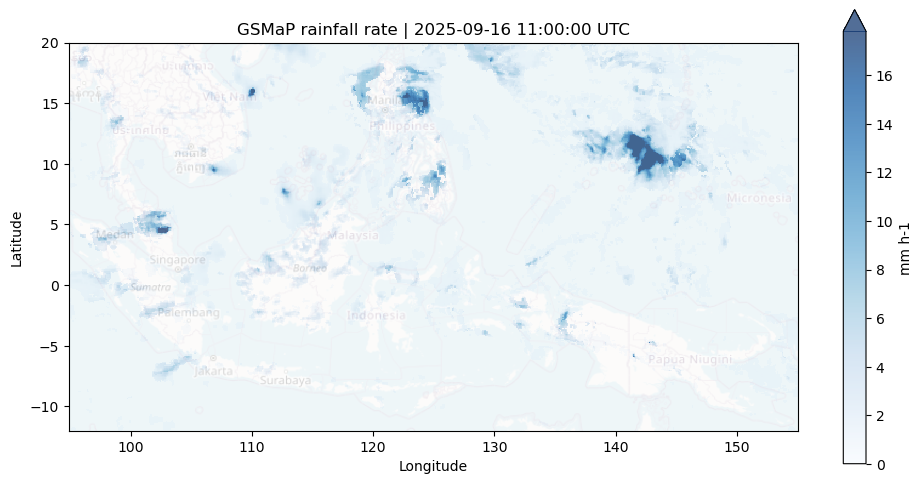

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'GSMaP rainfall rate | 2025-09-16 11:00:00 UTC'}, xlabel='Longitude', ylabel='Latitude'>)

In [11]:
# Select a timestep to inspect. Use -1 for the latest downloaded field.
time_index = -1
single_step = gsmap_ds["precipitation_rate"].isel(time=time_index)
mean_rain   = gsmap_ds["precipitation_rate"].mean("time", skipna=True)
max_rain    = gsmap_ds["precipitation_rate"].max("time", skipna=True)

intensity_vmax = compute_vmax(
    [single_step, max_rain],
    override=settings.get("plot_intensity_vmax"),
)
mean_vmax = compute_vmax(
    [mean_rain],
    override=settings.get("plot_mean_vmax"),
)

print(f"Shared intensity vmax (single-step & max plots): "
      f"{intensity_vmax:.2f} mm/h" if intensity_vmax is not None else
      "Shared intensity vmax: no positive rainfall pixels found.")
print(f"Mean-intensity vmax:                              "
      f"{mean_vmax:.2f} mm/h" if mean_vmax is not None else
      "Mean-intensity vmax: no positive rainfall pixels found.")

# Plot the selected timestep.
plot_gridded_map(
    single_step,
    title=f"GSMaP rainfall rate | {pd.to_datetime(single_step.time.values)} UTC",
    cmap="Blues",
    vmin=0,
    vmax=intensity_vmax,
    zero_as_nan=settings.get("plot_zero_as_nan", True),
    cbar_label="mm h-1",
)


# Step 9: Plot mean and maximum rainfall over the selected period

The mean field shows the average rainfall intensity during the event window.

The maximum field shows the highest hourly rainfall rate reached at each grid cell. This is often more relevant for flash-flood discussions than the period mean.

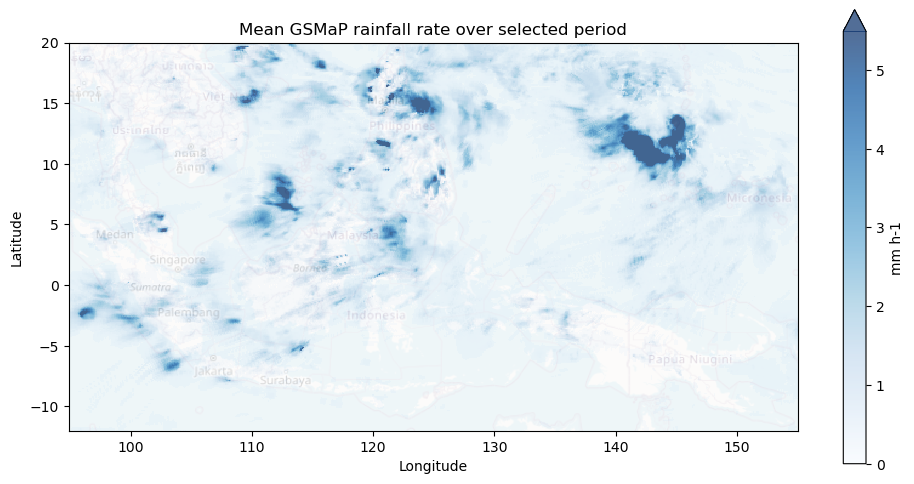

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'Mean GSMaP rainfall rate over selected period'}, xlabel='Longitude', ylabel='Latitude'>)

In [12]:
# mean_rain was already computed above; we re-use it here.
plot_gridded_map(
    mean_rain,
    title="Mean GSMaP rainfall rate over selected period",
    cmap="Blues",
    vmin=0,
    vmax=mean_vmax,
    zero_as_nan=settings.get("plot_zero_as_nan", True),
    cbar_label="mm h-1",
)


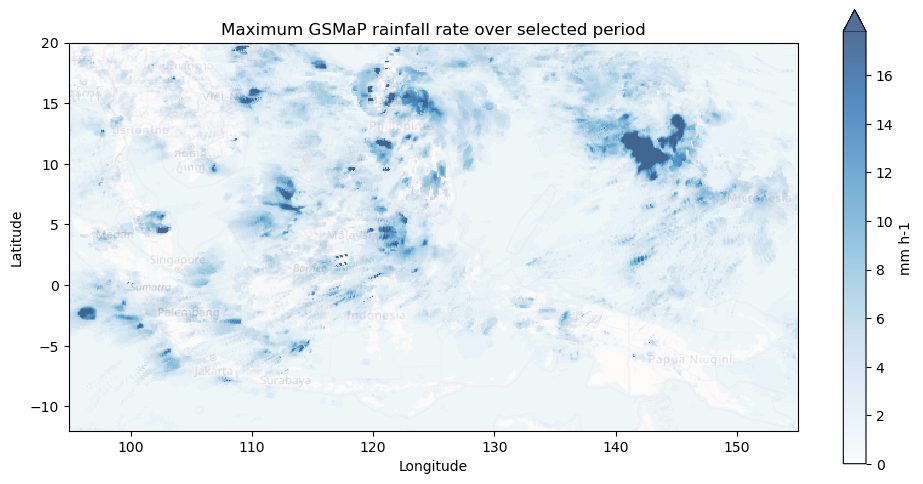

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'Maximum GSMaP rainfall rate over selected period'}, xlabel='Longitude', ylabel='Latitude'>)

In [13]:

plot_gridded_map(
    max_rain,
    title="Maximum GSMaP rainfall rate over selected period",
    cmap="Blues",
    vmin=0,
    vmax=intensity_vmax,
    zero_as_nan=settings.get("plot_zero_as_nan", True),
    cbar_label="mm h-1",
)


# Step 10: Check basic rainfall quality

Before using rainfall data in a nowcast, inspect whether the data is suitable.

Pay attention to:

- the maximum rainfall intensity;
- the number of rainy pixels;
- the amount of missing data;
- whether the selected event actually contains enough rainfall structure for motion estimation.

If there is almost no rainfall in the domain, a nowcast will not be meaningful.

In [14]:
def summarize_rainfall_quality(ds, threshold_mm_h):
    """Create a compact quality-control table for the selected GSMaP dataset."""
    rain = ds["precipitation_rate"]

    total_pixels = rain.size
    wet_pixels = int((rain >= threshold_mm_h).sum().values)
    missing_pixels = int(rain.isnull().sum().values)

    records = [
        {"diagnostic": "Number of timesteps", "value": int(rain.sizes["time"]), "unit": "hours"},
        {"diagnostic": "Minimum rainfall rate", "value": float(rain.min(skipna=True).values), "unit": "mm h-1"},
        {"diagnostic": "Mean rainfall rate", "value": float(rain.mean(skipna=True).values), "unit": "mm h-1"},
        {"diagnostic": "Maximum rainfall rate", "value": float(rain.max(skipna=True).values), "unit": "mm h-1"},
        {"diagnostic": "Wet pixels above threshold", "value": wet_pixels, "unit": f"pixels >= {threshold_mm_h} mm h-1"},
        {"diagnostic": "Wet-pixel fraction", "value": wet_pixels / total_pixels, "unit": "fraction of all time-space pixels"},
        {"diagnostic": "Missing pixels", "value": missing_pixels, "unit": "pixels"},
        {"diagnostic": "Missing-pixel fraction", "value": missing_pixels / total_pixels, "unit": "fraction of all time-space pixels"},
    ]

    return pd.DataFrame(records)


rainfall_qc = summarize_rainfall_quality(gsmap_ds, settings["rain_threshold_mm_h"])
rainfall_qc


,diagnostic,value,unit
0,Number of timesteps,12.000000,hours
1,Minimum rainfall rate,0.000000,mm h-1
2,Mean rainfall rate,0.387781,mm h-1
3,Maximum rainfall rate,159.244415,mm h-1
4,Wet pixels above threshold,404010.000000,pixels >= 0.1 mm h-1
5,Wet-pixel fraction,0.175060,fraction of all time-space pixels
6,Missing pixels,0.000000,pixels
7,Missing-pixel fraction,0.000000,fraction of all time-space pixels


## Exercise 2: Interpret the quality-control table

Use the quality-control table to answer:

1. Is this a dry, moderate, or intense rainfall event?
2. Are there enough rainy pixels for motion estimation?
3. Are there missing values that may affect later analysis?

# Step 11: Define city zoom functions

The full domain is useful for downloading and nowcasting, but it is often too large for interpretation.

The functions below create smaller plots around selected cities. In this notebook we use Phnom Penh and Vientiane, but the same approach can be used for any city, station, or catchment outlet.

In [15]:
def get_city_zoom_table(settings):
    """Return city zoom settings as a small table.

    The table is useful in a workshop because it makes all selected cities and
    zoom boxes explicit. Participants can edit the latitude, longitude, or buffer
    and immediately re-run the plots.
    """
    records = []

    for city in settings.get("city_zoom_locations", []):
        buffer_deg = float(settings.get("city_zoom_buffer_degrees", 2.0))
        lat = float(city["lat"])
        lon = float(city["lon"])

        records.append({
            "name": city["name"],
            "country": city.get("country", ""),
            "lat": lat,
            "lon": lon,
            "buffer_degrees": buffer_deg,
            "min_lon": lon - buffer_deg,
            "max_lon": lon + buffer_deg,
            "min_lat": lat - buffer_deg,
            "max_lat": lat + buffer_deg,
            "notes": city.get("notes", ""),
        })

    return pd.DataFrame(records)


def subset_dataarray_around_city(da, city, buffer_degrees):
    """Subset a DataArray to a square lon/lat box around one city.

    The function assumes that coordinates are named ``lat`` and ``lon``.
    It works with latitude in ascending or descending order, although earlier
    in this notebook we sort latitude ascending for convenience.
    """
    lat = float(city["lat"])
    lon = float(city["lon"])
    buffer_degrees = float(buffer_degrees)

    min_lon = lon - buffer_degrees
    max_lon = lon + buffer_degrees
    min_lat = lat - buffer_degrees
    max_lat = lat + buffer_degrees

    if da.lat.values[0] <= da.lat.values[-1]:
        lat_slice = slice(min_lat, max_lat)
    else:
        lat_slice = slice(max_lat, min_lat)

    return da.sel(lon=slice(min_lon, max_lon), lat=lat_slice)


def plot_city_zoom_field(
    da,
    settings,
    title_prefix,
    file_prefix=None,
    vmax=None,
    cbar_label=None,
):
    """Plot one rainfall field around each configured city.

    The city plots use the same map helper as the full-domain plots. This means
    that 0 values are transparent by default and an OpenStreetMap basemap is shown
    when `contextily` is installed.

    Pass ``vmax`` to keep the colour scale identical to the full-domain plot of
    the same field, so participants can compare zoom and full-domain figures
    directly. If ``vmax`` is None the plot auto-scales to the local maximum.
    """
    if not settings.get("city_zoom_enabled", True):
        print("City zooms are disabled. Set settings['city_zoom_enabled'] = True to enable them.")
        return

    buffer_degrees = settings.get("city_zoom_buffer_degrees", 2.0)

    for city in settings.get("city_zoom_locations", []):
        city_da = subset_dataarray_around_city(da, city, buffer_degrees)

        output_path = None
        if file_prefix is not None:
            safe_name = city["name"].lower().replace(" ", "_")
            output_path = figures_folder / f"{file_prefix}_{safe_name}.png"

        plot_gridded_map(
            city_da,
            title=(
                f"{title_prefix}\n"
                f"{city['name']} zoom, +/- {buffer_degrees} degrees"
            ),
            cmap="Blues",
            vmin=0,
            vmax=vmax,
            zero_as_nan=settings.get("plot_zero_as_nan", True),
            city=city,
            figure_size=(8, 6),
            cbar_label=(
                cbar_label
                if cbar_label is not None
                else city_da.attrs.get("units", "mm h-1")
            ),
            output_path=output_path,
        )


city_zoom_table = get_city_zoom_table(settings)
city_zoom_table


,name,country,lat,lon,buffer_degrees,min_lon,max_lon,min_lat,max_lat,notes
0,Phnom Penh,Cambodia,11.5564,104.9282,2.0,102.9282,106.9282,9.5564,13.5564,City-centre reference point; adjust if your pr...
1,Vientiane,Lao PDR,17.9757,102.6331,2.0,100.6331,104.6331,15.9757,19.9757,City-centre reference point; adjust if your pr...


# Step 12: Plot rainfall accumulation

For flood forecasting, hourly rainfall intensity is important, but accumulated rainfall is often easier to interpret.

Here we calculate:

- 3-hour accumulation ending at the latest timestep;
- 6-hour accumulation ending at the latest timestep;
- event-total accumulation over the full downloaded period.

Shared accumulation vmax: 57.37 mm


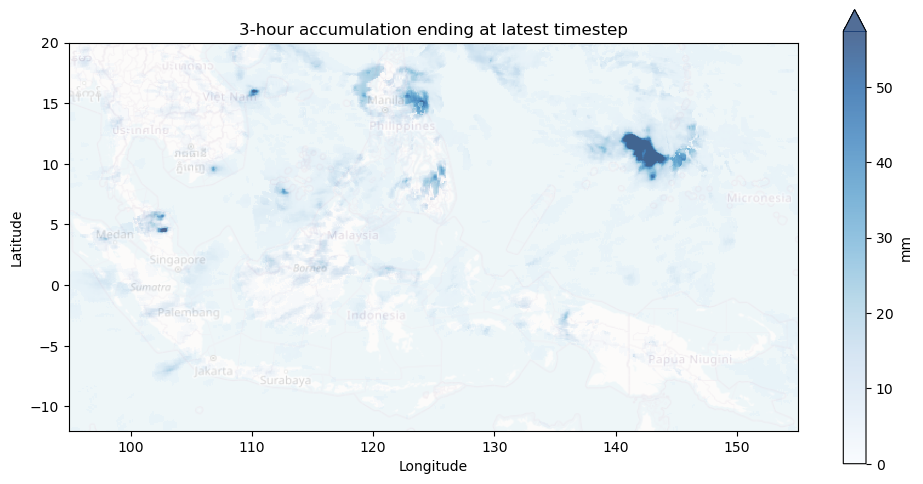

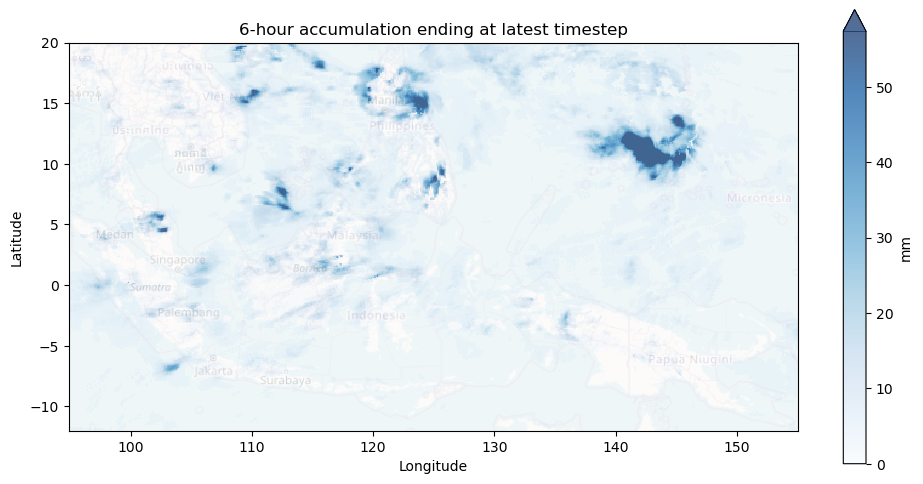

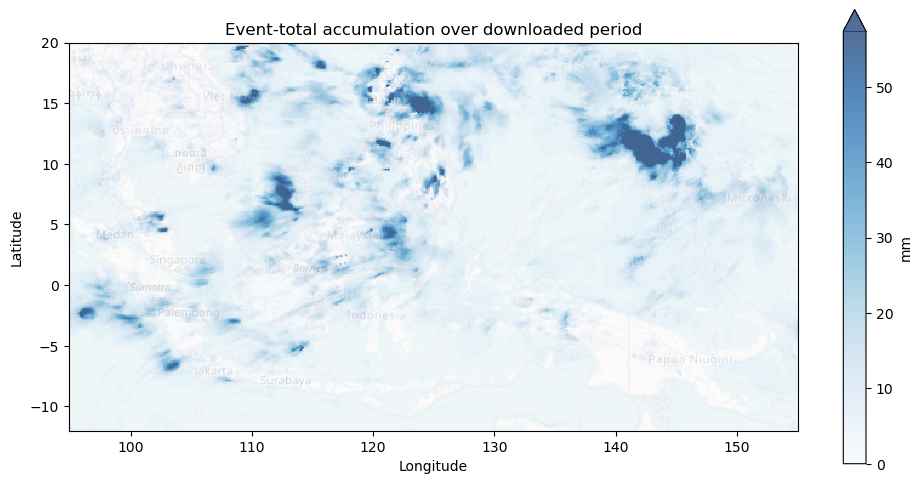

In [16]:
rain = gsmap_ds["precipitation_rate"]

accum_3h    = rain.rolling(time=3, min_periods=1).sum()
accum_6h    = rain.rolling(time=6, min_periods=1).sum()
accum_event = rain.sum("time", skipna=True)

# Shared colour-scale upper bound across the three accumulation plots.
# The event-total holds the highest values, so basing vmax on it (using a
# high percentile to ignore outliers) means:
#   - the event-total plot fills the colour bar nicely;
#   - the 3h and 6h plots look lighter, which correctly conveys that less
#     rain has accumulated over those shorter windows.
# All three plots therefore share one colour scale and can be compared visually.
accumulation_vmax = compute_vmax(
    [accum_3h.isel(time=-1), accum_6h.isel(time=-1), accum_event],
    override=settings.get("plot_accumulation_vmax"),
)
print(
    f"Shared accumulation vmax: {accumulation_vmax:.2f} mm"
    if accumulation_vmax is not None
    else "Shared accumulation vmax: no positive rainfall pixels found."
)

accumulation_products = {
    "3-hour accumulation ending at latest timestep": accum_3h.isel(time=-1),
    "6-hour accumulation ending at latest timestep": accum_6h.isel(time=-1),
    "Event-total accumulation over downloaded period": accum_event,
}

for title, field in accumulation_products.items():
    plot_gridded_map(
        field,
        title=title,
        cmap="Blues",
        vmin=0,
        vmax=accumulation_vmax,
        zero_as_nan=settings.get("plot_zero_as_nan", True),
        cbar_label="mm",
    )


# Step 13: Zoom in around Phnom Penh and Vientiane

These plots show the event-total rainfall accumulation and maximum observed rainfall around the selected cities.

This is useful during a workshop because participants can compare the regional view with the local city-scale interpretation.

Saved: gsmap_data\figures\observed_event_total_accumulation_city_zoom_phnom_penh.png


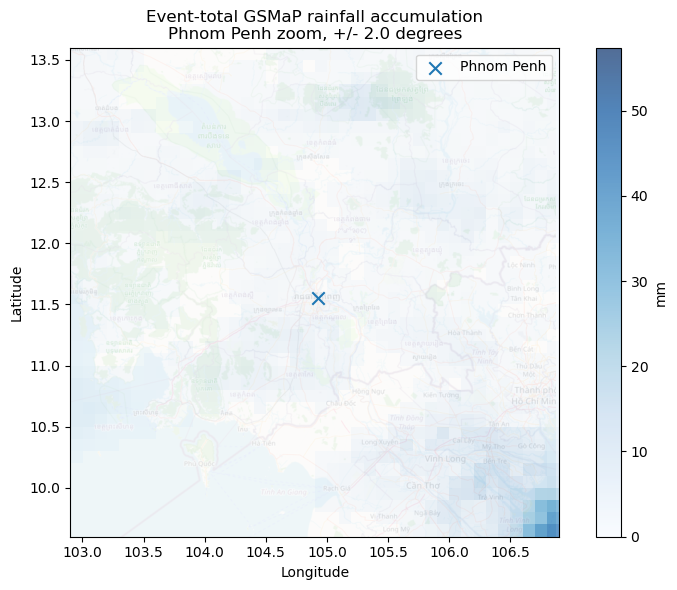

Saved: gsmap_data\figures\observed_event_total_accumulation_city_zoom_vientiane.png


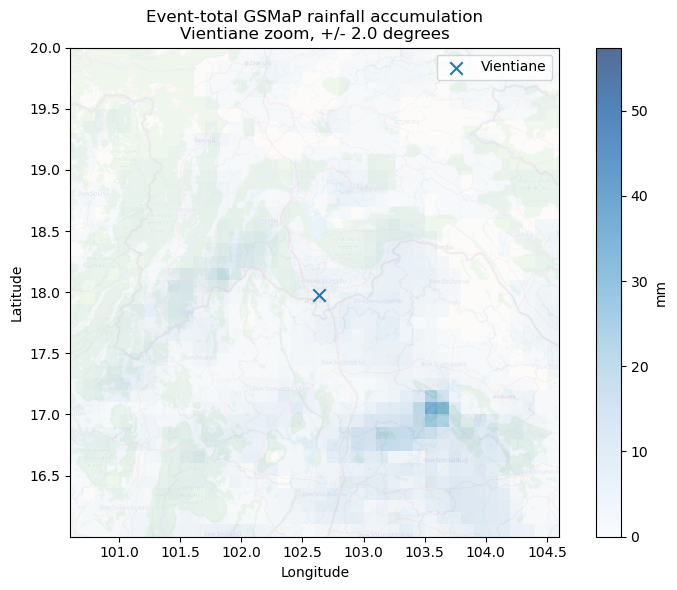

In [17]:
# Optional: city zooms for the event-total rainfall accumulation.
# Re-using accumulation_vmax keeps the colour scale identical to the
# full-domain accumulation plots above.
plot_city_zoom_field(
    accum_event,
    settings,
    title_prefix="Event-total GSMaP rainfall accumulation",
    file_prefix="observed_event_total_accumulation_city_zoom",
    vmax=accumulation_vmax,
    cbar_label="mm",
)


Saved: gsmap_data\figures\observed_max_city_zoom_phnom_penh.png


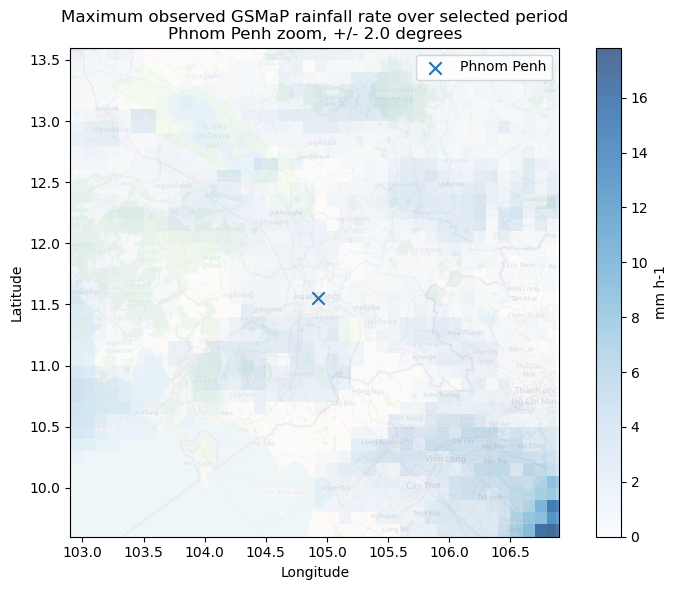

Saved: gsmap_data\figures\observed_max_city_zoom_vientiane.png


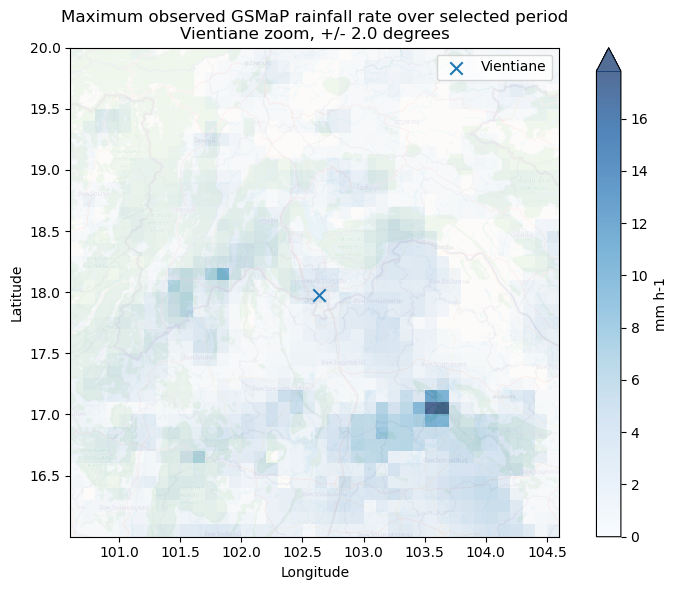

In [18]:
# Example: zoom in to the maximum observed rainfall field around Phnom Penh and Vientiane.
# Re-using intensity_vmax keeps the colour scale identical to the
# full-domain max-intensity plot above.
plot_city_zoom_field(
    max_rain,
    settings,
    title_prefix="Maximum observed GSMaP rainfall rate over selected period",
    file_prefix="observed_max_city_zoom",
    vmax=intensity_vmax,
    cbar_label="mm h-1",
)


## Exercise 3: Compare intensity and accumulation

Compare the hourly maximum rainfall and the event-total accumulation.

1. Does the highest rainfall occur near either city?
2. Is the event dominated by one intense hour or by several hours of moderate rainfall?
3. How does the answer change when you zoom in around the cities?
4. What would this imply for flash-flood risk?

# End of Tutorial 1

You have now downloaded GSMaP rainfall data, converted it to NetCDF, and inspected the event.

The NetCDF file in `gsmap_data/processed_netcdf` is the input for the second notebook, where we create a pySTEPS nowcast.